# BACE Baseline Comparison (7 Modelle)

Dieses Notebook vergleicht auf **demselben Scaffold-Split** sieben Baselines:
1. RF auf Graph-Features, die direkt aus denselben Atom-/Bond-Features wie `smiles_to_graph` aggregiert werden
2. RF auf RDKit-Deskriptoren (wie im Analysis-Ansatz)
3. ChebNet von Scratch
4. ChebNet mit Foundation-Checkpoint (Pretrained Init)
5. Standard-SEG (wie im üblichen Projekt-Setup)
6. SEG: Foundation-ChebNet direkt kopiert -> end-to-end Fine-Tuning
7. SEG: Foundation-ChebNet erst auf BACE (Cheb) finetunen -> dann in SEG -> end-to-end Fine-Tuning

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from rdkit import Chem, RDLogger
from rdkit.Chem import Descriptors

import deepchem as dc
from sklearn.ensemble import RandomForestClassifier

RDLogger.DisableLog('rdApp.warning')
RDLogger.DisableLog('rdApp.error')

# Ensure project root is importable before local package imports.
here = Path.cwd().resolve()
workspace_root = next((p for p in [here, *here.parents] if (p / 'models').exists()), here)
if str(workspace_root) not in sys.path:
    sys.path.insert(0, str(workspace_root))

from models.cheb_predictor import ChebPredictor, ChebPredictorConfig
from models.seg_predictor import SEGPredictor, SEGPredictorConfig
from utils.embedding_cache import EfficientEmbeddingCache
from utils.molecular_graph import smiles_to_graph

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

print(f'Workspace root: {workspace_root}')
print(f'Device: {device}')

No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
No normalization for NumAmideBonds. Feature removed!
No normalization for NumAtomStereoCenters. Feature removed!
No normalization for NumBridgeheadAtoms. Feature removed!
No normalization for NumHeterocycles. Feature removed!
No normalization for NumSpiroAtoms. Feature removed!
No normalization for NumUnspecifiedAtomStereoCenters. Feature removed!
No normalization for Phi. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'torch_geometric'
Skipped loading modules with transformers dependency. No module named 'transformers'
cannot import name 'HuggingFaceModel' from 'deepchem.models.torch_models' (c:\Users\robsc\Home\Dev\molfusion2\.venv\Lib\site-packages\deepchem\models\torch_models\__init__.py)
Skipped loading modules with pytorch-geometric depe

Workspace root: C:\Users\robsc\Home\Dev\molfusion2
Device: cuda


In [2]:
def to_binary01(y):
    y = np.asarray(y, dtype=np.float32).reshape(-1)
    y = np.where(np.isfinite(y), y, np.nan)
    if np.isnan(y).any():
        raise ValueError('Labels contain NaN values.')

    uniq = np.unique(y)
    if set(np.round(uniq).tolist()).issubset({0.0, 1.0}):
        return y.astype(np.float32)
    if set(np.round(uniq).tolist()).issubset({-1.0, 1.0}):
        return (y > 0).astype(np.float32)

    raise ValueError(f'Unsupported binary labels: {uniq}')

def find_best_threshold(y_true, y_pred_proba):
    y_true = np.asarray(y_true, dtype=np.float32).reshape(-1)
    y_pred_proba = np.asarray(y_pred_proba, dtype=np.float32).reshape(-1)
    mask = np.isfinite(y_pred_proba)
    y_true = y_true[mask]
    y_pred_proba = np.clip(y_pred_proba[mask], 0.0, 1.0)

    best_thr = 0.5
    best_f1 = -1.0
    best_acc = -1.0

    for thr in np.linspace(0.05, 0.95, 181):
        y_hat = (y_pred_proba >= thr).astype(np.float32)
        tp = float(np.sum((y_hat == 1) & (y_true == 1)))
        tn = float(np.sum((y_hat == 0) & (y_true == 0)))
        fp = float(np.sum((y_hat == 1) & (y_true == 0)))
        fn = float(np.sum((y_hat == 0) & (y_true == 1)))
        acc = float((tp + tn) / max(tp + tn + fp + fn, 1.0))
        precision = float(tp / max(tp + fp, 1.0))
        recall = float(tp / max(tp + fn, 1.0))
        f1 = float(2.0 * precision * recall / max(precision + recall, 1e-12))

        if (f1 > best_f1) or (np.isclose(f1, best_f1) and acc > best_acc):
            best_f1 = f1
            best_acc = acc
            best_thr = float(thr)

    return best_thr

def classification_metrics(y_true, y_pred_proba, threshold=0.5):
    y_true = np.asarray(y_true, dtype=np.float32).reshape(-1)
    y_pred_proba = np.asarray(y_pred_proba, dtype=np.float32).reshape(-1)
    y_pred_proba = np.clip(y_pred_proba, 0.0, 1.0)
    mask = np.isfinite(y_pred_proba)
    y_true = y_true[mask]
    y_pred_proba = y_pred_proba[mask]
    y_pred = (y_pred_proba >= threshold).astype(np.float32)

    from sklearn.metrics import roc_auc_score, accuracy_score, f1_score
    return {
        'roc_auc': float(roc_auc_score(y_true, y_pred_proba)),
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'f1': float(f1_score(y_true, y_pred, zero_division=0)),
    }

In [3]:
tasks, datasets, _ = dc.molnet.load_bace_classification(featurizer='ECFP', splitter='scaffold')
train_dc, valid_dc, test_dc = datasets

train_smiles = list(train_dc.ids)
valid_smiles = list(valid_dc.ids)
test_smiles = list(test_dc.ids)

train_y_arr = to_binary01(train_dc.y)
valid_y_arr = to_binary01(valid_dc.y)
test_y_arr = to_binary01(test_dc.y)

train_y = train_y_arr.tolist()
valid_y = valid_y_arr.tolist()

print(f'BACE sizes -> train={len(train_smiles)}, val={len(valid_smiles)}, test={len(test_smiles)}')
print(f'Class balance -> train={train_y_arr.mean():.3f}, val={valid_y_arr.mean():.3f}, test={test_y_arr.mean():.3f}')

BACE sizes -> train=1210, val=151, test=152
Class balance -> train=0.426, val=0.556, test=0.605


In [4]:
def _impute_with_train_median(train_X, valid_X, test_X):
    med = np.nanmedian(train_X, axis=0)
    med = np.where(np.isfinite(med), med, 0.0).astype(np.float32)
    def _imp(X):
        X = np.asarray(X, dtype=np.float32)
        mask = ~np.isfinite(X)
        if mask.any():
            X = X.copy()
            X[mask] = np.take(med, np.where(mask)[1])
        return X
    return _imp(train_X), _imp(valid_X), _imp(test_X)

def graph_feature_vector_from_smiles(smiles):
    g = smiles_to_graph(smiles, add_hydrogens=False)
    X = np.asarray(g.X, dtype=np.float32)
    ew = np.asarray(g.edge_weight, dtype=np.float32)

    x_sum = X.sum(axis=0)
    x_mean = X.mean(axis=0)
    x_std = X.std(axis=0)

    n_nodes = float(g.n_nodes)
    n_edges_undir = float(g.edge_index.shape[1] // 2)
    ew_mean = float(ew.mean()) if ew.size else 0.0
    ew_std = float(ew.std()) if ew.size else 0.0
    ew_sum = float(ew.sum()) if ew.size else 0.0

    return np.concatenate([x_sum, x_mean, x_std, np.array([n_nodes, n_edges_undir, ew_mean, ew_std, ew_sum], dtype=np.float32)])

def build_graph_feature_matrix(smiles_list):
    rows = []
    for smi in smiles_list:
        try:
            rows.append(graph_feature_vector_from_smiles(smi))
        except Exception:
            rows.append(np.full((89,), np.nan, dtype=np.float32))
    return np.vstack(rows).astype(np.float32)

def rdkit_descriptor_matrix(smiles_list):
    desc_names = [name for name, _ in Descriptors.descList]
    n_desc = len(desc_names)
    rows = []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            rows.append(np.full((n_desc,), np.nan, dtype=np.float32))
            continue
        all_descs = Descriptors.CalcMolDescriptors(mol)
        row = []
        for name in desc_names:
            try:
                row.append(float(all_descs.get(name, np.nan)))
            except Exception:
                row.append(np.nan)
        rows.append(np.asarray(row, dtype=np.float32))
    return np.vstack(rows).astype(np.float32), desc_names

In [5]:
# --- Baseline 1: RF auf Graph-Features (aus denselben atomaren/bindungsbasierten Inputs wie MolGraph) ---
g_train = build_graph_feature_matrix(train_smiles)
g_valid = build_graph_feature_matrix(valid_smiles)
g_test = build_graph_feature_matrix(test_smiles)
g_train, g_valid, g_test = _impute_with_train_median(g_train, g_valid, g_test)

rf_graph = RandomForestClassifier(
    n_estimators=1200,
    max_features='sqrt',
    class_weight='balanced',
    random_state=seed,
    n_jobs=-1,
)
rf_graph.fit(g_train, train_y_arr)

rf_graph_valid_proba = rf_graph.predict_proba(g_valid)[:, 1]
rf_graph_thr = find_best_threshold(valid_y_arr, rf_graph_valid_proba)
rf_graph_test_proba = rf_graph.predict_proba(g_test)[:, 1]
rf_graph_metrics = classification_metrics(test_y_arr, rf_graph_test_proba, threshold=rf_graph_thr)

print('RF Graph feature dim:', g_train.shape[1])
print('RF Graph threshold:', rf_graph_thr)
print('RF Graph metrics:', rf_graph_metrics)

RF Graph feature dim: 89
RF Graph threshold: 0.10999999999999999
RF Graph metrics: {'roc_auc': 0.8038949275362319, 'accuracy': 0.7039473684210527, 'f1': 0.7926267281105991}


In [6]:
# --- Baseline 2: RF auf RDKit-Deskriptoren ---
d_train, desc_names = rdkit_descriptor_matrix(train_smiles)
d_valid, _ = rdkit_descriptor_matrix(valid_smiles)
d_test, _ = rdkit_descriptor_matrix(test_smiles)
d_train, d_valid, d_test = _impute_with_train_median(d_train, d_valid, d_test)

rf_desc = RandomForestClassifier(
    n_estimators=1200,
    max_features='sqrt',
    class_weight='balanced',
    random_state=seed,
    n_jobs=-1,
)
rf_desc.fit(d_train, train_y_arr)

rf_desc_valid_proba = rf_desc.predict_proba(d_valid)[:, 1]
rf_desc_thr = find_best_threshold(valid_y_arr, rf_desc_valid_proba)
rf_desc_test_proba = rf_desc.predict_proba(d_test)[:, 1]
rf_desc_metrics = classification_metrics(test_y_arr, rf_desc_test_proba, threshold=rf_desc_thr)

print('RF RDKit descriptor dim:', d_train.shape[1])
print('RF RDKit threshold:', rf_desc_thr)
print('RF RDKit metrics:', rf_desc_metrics)

RF RDKit descriptor dim: 217
RF RDKit threshold: 0.27999999999999997
RF RDKit metrics: {'roc_auc': 0.8002717391304348, 'accuracy': 0.7368421052631579, 'f1': 0.7872340425531915}


In [7]:
CHEB_CFG = {
    'hidden_channels': 64,
    'K': 3,
    'num_layers': 2,
    'pool': 'sum',
}

VANILLA_FIT_KWARGS = {
    'batch_size': 64,
    'num_epochs': 200,
    'learning_rate': 1e-3,
    'weight_decay': 1e-4,
    'patience': 30,
}

# Keep this aligned with the two-stage transfer setup from the pretraining notebook.
CHEB_FIT_KWARGS = {
    'batch_size': 64,
    'frozen_epochs': 40,
    'unfreeze_epochs': 160,
    'head_lr': 5e-4,
    'encoder_lr': 5e-5,
    'weight_decay': 1e-1,
    'patience': 30,
}

# Standard SEG setup aligned with the project-wide multi-seed notebook defaults.
SEG_FIT_KWARGS = {
    'hidden_channels': 64,
    'K': 3,
    'num_layers': 2,
    'pool': 'sum',
    'set2set_processing_steps': 6,
    'fusion': 'cross_mha',
    'fusion_dim': 64,
    'fusion_n_heads': 8,
    'text_proj_init': 'xavier',
    'text_proj_init_gain': 0.1,
    'freeze_text_proj': True,
    'dropout': 0.3,
    'fusion_dropout': 0.3,
    'head_dropout': 0.5,
    'weight_decay': 1e-1,
    'head_type': 'mlp',
    'head_hidden_dim': 32,
    'learning_rate': 5e-3,
    'batch_size': 64,
    'num_epochs': 200,
    'patience': 30,
    'scheduler': 'cosine',
    'scheduler_patience': 5,
    'scheduler_factor': 0.5,
    'min_lr': 1e-6,
    'grad_clip': None,
}

# SEG variant that can ingest the pretrained ChebNet encoder weights directly.
SEG_CHEB_INIT_FIT_KWARGS = {**SEG_FIT_KWARGS, **{
    'hidden_channels': CHEB_CFG['hidden_channels'],
    'K': CHEB_CFG['K'],
    'num_layers': CHEB_CFG['num_layers'],
    'pool': CHEB_CFG['pool'],
    'learning_rate': 2e-4,
}}

def make_bace_config():
    return ChebPredictorConfig(
        task='classification',
        hidden_channels=CHEB_CFG['hidden_channels'],
        K=CHEB_CFG['K'],
        num_layers=CHEB_CFG['num_layers'],
        pool=CHEB_CFG['pool'],
        dropout=0.3,
        lambda_max=2.0,
        add_hydrogens=False,
        head_hidden_dim=32,
        head_dropout=0.5,
    )

def make_seg_config(text_embedding_dim):
    return SEGPredictorConfig(
        task='classification',
        hidden_channels=SEG_FIT_KWARGS['hidden_channels'],
        K=SEG_FIT_KWARGS['K'],
        num_layers=SEG_FIT_KWARGS['num_layers'],
        dropout=SEG_FIT_KWARGS['dropout'],
        pool=SEG_FIT_KWARGS['pool'],
        set2set_processing_steps=SEG_FIT_KWARGS['set2set_processing_steps'],
        text_embedding_dim=int(text_embedding_dim),
        text_projection_dim=SEG_FIT_KWARGS['fusion_dim'],
        text_proj_init=SEG_FIT_KWARGS['text_proj_init'],
        text_proj_init_gain=SEG_FIT_KWARGS['text_proj_init_gain'],
        freeze_text_proj=SEG_FIT_KWARGS['freeze_text_proj'],
        fusion=SEG_FIT_KWARGS['fusion'],
        fusion_dim=SEG_FIT_KWARGS['fusion_dim'],
        fusion_n_heads=SEG_FIT_KWARGS['fusion_n_heads'],
        fusion_dropout=SEG_FIT_KWARGS['fusion_dropout'],
        head_type=SEG_FIT_KWARGS['head_type'],
        head_hidden_dim=SEG_FIT_KWARGS['head_hidden_dim'],
        head_dropout=SEG_FIT_KWARGS['head_dropout'],
    )

def make_seg_pretrained_graph_config(text_embedding_dim):
    return SEGPredictorConfig(
        task='classification',
        hidden_channels=SEG_CHEB_INIT_FIT_KWARGS['hidden_channels'],
        K=SEG_CHEB_INIT_FIT_KWARGS['K'],
        num_layers=SEG_CHEB_INIT_FIT_KWARGS['num_layers'],
        dropout=SEG_CHEB_INIT_FIT_KWARGS['dropout'],
        pool=SEG_CHEB_INIT_FIT_KWARGS['pool'],
        set2set_processing_steps=SEG_CHEB_INIT_FIT_KWARGS['set2set_processing_steps'],
        text_embedding_dim=int(text_embedding_dim),
        text_projection_dim=SEG_CHEB_INIT_FIT_KWARGS['fusion_dim'],
        text_proj_init=SEG_CHEB_INIT_FIT_KWARGS['text_proj_init'],
        text_proj_init_gain=SEG_CHEB_INIT_FIT_KWARGS['text_proj_init_gain'],
        freeze_text_proj=SEG_CHEB_INIT_FIT_KWARGS['freeze_text_proj'],
        fusion=SEG_CHEB_INIT_FIT_KWARGS['fusion'],
        fusion_dim=SEG_CHEB_INIT_FIT_KWARGS['fusion_dim'],
        fusion_n_heads=SEG_CHEB_INIT_FIT_KWARGS['fusion_n_heads'],
        fusion_dropout=SEG_CHEB_INIT_FIT_KWARGS['fusion_dropout'],
        head_type=SEG_CHEB_INIT_FIT_KWARGS['head_type'],
        head_hidden_dim=SEG_CHEB_INIT_FIT_KWARGS['head_hidden_dim'],
        head_dropout=SEG_CHEB_INIT_FIT_KWARGS['head_dropout'],
    )

def load_encoder_from_pretraining(predictor, pretrain_checkpoint_path):
    ckpt = torch.load(pretrain_checkpoint_path, map_location=predictor.device, weights_only=False)
    ckpt_cfg = ckpt.get('cheb_cfg', {})
    required_keys = ('hidden_channels', 'K', 'num_layers', 'pool')
    mismatches = []
    for k in required_keys:
        if k in ckpt_cfg and ckpt_cfg[k] != CHEB_CFG[k]:
            mismatches.append((k, ckpt_cfg[k], CHEB_CFG[k]))
    if mismatches:
        mismatch_msg = '; '.join([f"{k}: ckpt={a} current={b}" for (k, a, b) in mismatches])
        raise RuntimeError(f'Checkpoint encoder config mismatch: {mismatch_msg}')

    pre_state = ckpt['model_state_dict']
    enc_state = {k.replace('encoder.', '', 1): v for k, v in pre_state.items() if k.startswith('encoder.')}
    predictor._encoder.load_state_dict(enc_state, strict=True)

    # Optional: load pooling weights if checkpoint contains them and shapes match.
    pool_state = {k.replace('pooling.', '', 1): v for k, v in pre_state.items() if k.startswith('pooling.')}
    if pool_state:
        try:
            predictor._pooling.load_state_dict(pool_state, strict=True)
            print('Loaded pooling weights from pretraining checkpoint.')
        except Exception as exc:
            print(f'Pooling weights not loaded (shape or module mismatch): {exc}')

def make_cheb_backbone_from_pretraining(pretrain_checkpoint_path, sample_smiles):
    cheb_backbone = ChebPredictor(config=make_bace_config(), device=str(device))
    _, in_channels = cheb_backbone._precompute_graphs(sample_smiles, verbose=False)
    cheb_backbone._in_channels = in_channels
    cheb_backbone._build_model()
    load_encoder_from_pretraining(cheb_backbone, pretrain_checkpoint_path)
    cheb_backbone._is_fitted = True
    return cheb_backbone

def fit_two_stage(
    predictor,
    train_smiles, train_y,
    valid_smiles, valid_y,
    *,
    seed=42,
    batch_size=32,
    frozen_epochs=40,
    unfreeze_epochs=160,
    head_lr=5e-4,
    encoder_lr=5e-5,
    weight_decay=1e-1,
    patience=30,
    pretrained_ckpt=None,
    verbose=True,
):
    train_graphs, in_channels = predictor._precompute_graphs(train_smiles, verbose=verbose)
    valid_graphs, _ = predictor._precompute_graphs(valid_smiles, verbose=verbose)
    predictor._in_channels = in_channels
    predictor._build_model()

    if pretrained_ckpt is not None:
        load_encoder_from_pretraining(predictor, pretrained_ckpt)

    y_train = np.asarray(train_y, dtype=np.float32)
    y_valid = np.asarray(valid_y, dtype=np.float32)
    train_idx = np.arange(len(train_smiles))
    valid_idx = list(range(len(valid_smiles)))
    loss_fn = nn.BCELoss()

    rng = np.random.default_rng(seed)
    history = {'train_loss': [], 'val_loss': [], 'stage': []}
    best_val = float('inf')
    best_state = None
    stale = 0

    # Stage 1: freeze encoder+pooling, train head only.
    for p in predictor._encoder.parameters():
        p.requires_grad = False
    for p in predictor._pooling.parameters():
        p.requires_grad = False
    for p in predictor._head.parameters():
        p.requires_grad = True

    opt_head = torch.optim.Adam(
        list(predictor._head.parameters()),
        lr=head_lr,
        weight_decay=weight_decay,
    )

    for epoch in range(1, frozen_epochs + 1):
        tr = predictor._train_epoch(train_graphs, y_train, train_idx, batch_size, opt_head, loss_fn, rng)
        vl = predictor._evaluate(valid_graphs, y_valid, valid_idx, batch_size, loss_fn)
        history['train_loss'].append(float(tr))
        history['val_loss'].append(float(vl))
        history['stage'].append('frozen')

        if verbose and (epoch == 1 or epoch % 5 == 0):
            print(f'[frozen] epoch {epoch:03d} | train_bce={tr:.6f} | val_bce={vl:.6f}')

        if vl < best_val:
            best_val = float(vl)
            best_state = predictor._get_state_dict()
            stale = 0
        else:
            stale += 1
            if stale >= patience:
                if verbose:
                    print(f'Early stop in frozen stage at epoch {epoch}')
                break

    # Stage 2: unfreeze all; smaller lr for encoder/pooling.
    for p in predictor._encoder.parameters():
        p.requires_grad = True
    for p in predictor._pooling.parameters():
        p.requires_grad = True
    for p in predictor._head.parameters():
        p.requires_grad = True

    opt_full = torch.optim.Adam(
        [
            {'params': list(predictor._encoder.parameters()) + list(predictor._pooling.parameters()), 'lr': encoder_lr},
            {'params': list(predictor._head.parameters()), 'lr': head_lr},
        ],
        weight_decay=weight_decay,
    )

    stale = 0
    for epoch in range(1, unfreeze_epochs + 1):
        tr = predictor._train_epoch(train_graphs, y_train, train_idx, batch_size, opt_full, loss_fn, rng)
        vl = predictor._evaluate(valid_graphs, y_valid, valid_idx, batch_size, loss_fn)
        history['train_loss'].append(float(tr))
        history['val_loss'].append(float(vl))
        history['stage'].append('unfreeze')

        if verbose and (epoch == 1 or epoch % 5 == 0):
            print(f'[unfreeze] epoch {epoch:03d} | train_bce={tr:.6f} | val_bce={vl:.6f}')

        if vl < best_val:
            best_val = float(vl)
            best_state = predictor._get_state_dict()
            stale = 0
        else:
            stale += 1
            if stale >= patience:
                if verbose:
                    print(f'Early stop in unfreeze stage at epoch {epoch}')
                break

    if best_state is not None:
        predictor._load_state_dict(best_state)
    predictor._is_fitted = True

    return history, best_val

In [8]:
# Two-stage transfer for SEG to reduce catastrophic forgetting after Cheb init.
SEG_TRANSFER_FIT_KWARGS = {
    'batch_size': 64,
    'frozen_epochs': 30,
    'unfreeze_epochs': 170,
    'fusion_lr': 2e-4,
    'encoder_lr': 5e-5,
    'weight_decay': 1e-1,
    'patience': 30,
}

def fit_seg_two_stage(
    predictor,
    train_smiles, train_y,
    valid_smiles, valid_y,
    *,
    train_text_embeddings,
    valid_text_embeddings,
    seed=42,
    batch_size=64,
    frozen_epochs=30,
    unfreeze_epochs=170,
    fusion_lr=2e-4,
    encoder_lr=5e-5,
    weight_decay=1e-1,
    patience=30,
    verbose=True,
):
    if predictor._encoder is None or predictor._fusion is None or predictor._head is None:
        train_graphs, in_channels = predictor._precompute_graphs(train_smiles, verbose=verbose)
        valid_graphs, _ = predictor._precompute_graphs(valid_smiles, verbose=verbose)
        predictor._in_channels = in_channels
        predictor._build_model()
    else:
        train_graphs, _ = predictor._precompute_graphs(train_smiles, verbose=verbose)
        valid_graphs, _ = predictor._precompute_graphs(valid_smiles, verbose=verbose)

    if isinstance(train_text_embeddings, torch.Tensor):
        train_text_emb = train_text_embeddings.detach().cpu().numpy()
    else:
        train_text_emb = np.asarray(train_text_embeddings, dtype=np.float32)

    if isinstance(valid_text_embeddings, torch.Tensor):
        valid_text_emb = valid_text_embeddings.detach().cpu().numpy()
    else:
        valid_text_emb = np.asarray(valid_text_embeddings, dtype=np.float32)

    y_train = np.asarray(train_y, dtype=np.float32)
    y_valid = np.asarray(valid_y, dtype=np.float32)
    train_idx = np.arange(len(train_smiles))
    valid_idx = list(range(len(valid_smiles)))

    is_multilabel = (predictor.config.num_tasks > 1)
    if predictor.config.task == 'classification':
        loss_fn = nn.BCELoss(reduction='none') if is_multilabel else nn.BCELoss()
    else:
        loss_fn = nn.MSELoss(reduction='none') if is_multilabel else nn.MSELoss()

    rng = np.random.default_rng(seed)
    history = {'train_loss': [], 'val_loss': [], 'stage': []}
    best_val = float('inf')
    best_state = None
    stale = 0

    # Stage 1: freeze graph encoder/pooling, adapt fusion/head first.
    for p in predictor._encoder.parameters():
        p.requires_grad = False
    for p in predictor._pooling.parameters():
        p.requires_grad = False
    for p in predictor._fusion.parameters():
        p.requires_grad = True
    for p in predictor._head.parameters():
        p.requires_grad = True

    stage1_params = list(predictor._fusion.parameters()) + list(predictor._head.parameters())
    if predictor._text_proj is not None:
        for p in predictor._text_proj.parameters():
            p.requires_grad = True
        stage1_params += list(predictor._text_proj.parameters())

    opt_stage1 = torch.optim.AdamW(stage1_params, lr=fusion_lr, weight_decay=weight_decay)

    for epoch in range(1, frozen_epochs + 1):
        tr = predictor._train_epoch(
            train_graphs, train_text_emb, y_train, train_idx, batch_size, opt_stage1, loss_fn, rng,
            is_multilabel=is_multilabel,
        )
        vl = predictor._evaluate(
            valid_graphs, valid_text_emb, y_valid, valid_idx, batch_size, loss_fn,
            is_multilabel=is_multilabel,
        )
        history['train_loss'].append(float(tr))
        history['val_loss'].append(float(vl))
        history['stage'].append('frozen')

        if verbose and (epoch == 1 or epoch % 5 == 0):
            print(f'[seg frozen] epoch {epoch:03d} | train={tr:.6f} | val={vl:.6f}')

        if vl < best_val:
            best_val = float(vl)
            best_state = predictor._get_state_dict()
            stale = 0
        else:
            stale += 1
            if stale >= patience:
                if verbose:
                    print(f'SEG early stop in frozen stage at epoch {epoch}')
                break

    # Stage 2: unfreeze all with lower lr for graph branch.
    for p in predictor._encoder.parameters():
        p.requires_grad = True
    for p in predictor._pooling.parameters():
        p.requires_grad = True
    for p in predictor._fusion.parameters():
        p.requires_grad = True
    for p in predictor._head.parameters():
        p.requires_grad = True

    graph_params = list(predictor._encoder.parameters()) + list(predictor._pooling.parameters())
    fusion_head_params = list(predictor._fusion.parameters()) + list(predictor._head.parameters())
    if predictor._text_proj is not None:
        fusion_head_params += list(predictor._text_proj.parameters())

    opt_stage2 = torch.optim.AdamW(
        [
            {'params': graph_params, 'lr': encoder_lr},
            {'params': fusion_head_params, 'lr': fusion_lr},
        ],
        weight_decay=weight_decay,
    )

    stale = 0
    for epoch in range(1, unfreeze_epochs + 1):
        tr = predictor._train_epoch(
            train_graphs, train_text_emb, y_train, train_idx, batch_size, opt_stage2, loss_fn, rng,
            is_multilabel=is_multilabel,
        )
        vl = predictor._evaluate(
            valid_graphs, valid_text_emb, y_valid, valid_idx, batch_size, loss_fn,
            is_multilabel=is_multilabel,
        )
        history['train_loss'].append(float(tr))
        history['val_loss'].append(float(vl))
        history['stage'].append('unfreeze')

        if verbose and (epoch == 1 or epoch % 5 == 0):
            print(f'[seg unfreeze] epoch {epoch:03d} | train={tr:.6f} | val={vl:.6f}')

        if vl < best_val:
            best_val = float(vl)
            best_state = predictor._get_state_dict()
            stale = 0
        else:
            stale += 1
            if stale >= patience:
                if verbose:
                    print(f'SEG early stop in unfreeze stage at epoch {epoch}')
                break

    if best_state is not None:
        predictor._load_state_dict(best_state)
    predictor._is_fitted = True

    return history, best_val

In [9]:
# --- Baseline 3: ChebNet from scratch ---
cheb_scratch = ChebPredictor(config=make_bace_config(), device=str(device))
scratch_hist = cheb_scratch.fit(
    train_smiles,
    train_y,
    val_smiles=valid_smiles,
    val_labels=valid_y,
    num_epochs=VANILLA_FIT_KWARGS['num_epochs'],
    batch_size=VANILLA_FIT_KWARGS['batch_size'],
    learning_rate=VANILLA_FIT_KWARGS['learning_rate'],
    weight_decay=VANILLA_FIT_KWARGS['weight_decay'],
    patience=VANILLA_FIT_KWARGS['patience'],
    seed=seed,
    verbose=True,
)

cheb_scratch_best_val = float(np.min(scratch_hist['val_loss']))
cheb_scratch_valid_proba = cheb_scratch.predict_batch(valid_smiles)
cheb_scratch_thr = find_best_threshold(valid_y_arr, cheb_scratch_valid_proba)
cheb_scratch_test_proba = cheb_scratch.predict_batch(test_smiles)
cheb_scratch_metrics = classification_metrics(test_y_arr, cheb_scratch_test_proba, threshold=cheb_scratch_thr)

# --- Baseline 4: Pretrained encoder + echtes Fine-Tuning (2-stage) ---
# Choose which pretraining stage checkpoint to use.
# Options: 'stage1_node' (node-masking pretraining) or 'stage2_descriptor' (descriptor pretraining).
PRETRAIN_STAGE_TO_USE = 'stage1_node'
REQUIRED_PRETRAIN_STAGE = PRETRAIN_STAGE_TO_USE

def resolve_config_specific_checkpoint(workspace_root, cheb_cfg, required_stage=REQUIRED_PRETRAIN_STAGE):
    ckpt_dir = workspace_root / 'cache' / 'chemeleon_pretraining'
    if not ckpt_dir.exists():
        raise FileNotFoundError(f'Checkpoint directory not found: {ckpt_dir}')

    if required_stage not in {None, 'stage1_node', 'stage2_descriptor'}:
        raise ValueError(
            f"Unsupported required_stage={required_stage!r}. "
            "Use None, 'stage1_node', or 'stage2_descriptor'."
        )

    patterns = [
        (
            f"cheb_foundation_stage1__h{cheb_cfg['hidden_channels']}__"
            f"L{cheb_cfg['num_layers']}__"
            f"K{cheb_cfg['K']}__*.pt"
        ),
        (
            f"cheb_foundation_2stage__h{cheb_cfg['hidden_channels']}__"
            f"L{cheb_cfg['num_layers']}__"
            f"K{cheb_cfg['K']}__*.pt"
        ),
        (
            f"cheb_foundation__h{cheb_cfg['hidden_channels']}__"
            f"L{cheb_cfg['num_layers']}__"
            f"K{cheb_cfg['K']}__*.pt"
        ),
    ]

    candidates = []
    for pat in patterns:
        for p in ckpt_dir.glob(pat):
            if p.name in {'cheb_foundation_pretrain.pt', 'cheb_foundation_pretrain_stage1.pt'} or '__fallback__' in p.name:
                continue
            candidates.append(p)

    # Deduplicate while preserving order.
    uniq = []
    seen = set()
    for p in candidates:
        s = str(p.resolve())
        if s not in seen:
            uniq.append(p)
            seen.add(s)
    candidates = uniq

    ranked = []
    for p in candidates:
        score = float('inf')
        stage_ok = False
        stage_val = None
        try:
            payload = torch.load(p, map_location='cpu', weights_only=False)
            if isinstance(payload, dict):
                raw = payload.get('best_val_masked_mse', None)
                if raw is not None:
                    score = float(raw)
                stage_val = payload.get('pretraining_stage', None)
                if required_stage is None:
                    stage_ok = True
                else:
                    stage_ok = (stage_val == required_stage)
        except Exception:
            pass

        # Prioritize required stage first, then best val, then newest file.
        ranked.append((0 if stage_ok else 1, score, -p.stat().st_mtime, p, stage_val))

    if ranked:
        ranked.sort(key=lambda t: (t[0], t[1], t[2]))
        stage_priority, best_score, _, best_path, best_stage = ranked[0]
        if required_stage is not None and stage_priority != 0:
            print(
                f"Warning: no checkpoint with pretraining_stage='{required_stage}' found; "
                "falling back to best available config-matching checkpoint."
            )
        if np.isfinite(best_score):
            print(f"Checkpoint selection: best pretrain val_masked_mse={best_score:.6f}")
        else:
            print('Checkpoint selection: no best_val_masked_mse metadata found; using newest matching file')
        print(f"Checkpoint stage metadata: {best_stage}")
        return best_path

    alias_candidates = []
    if required_stage == 'stage1_node':
        alias_candidates = [
            ckpt_dir / 'cheb_foundation_pretrain_stage1.pt',
            ckpt_dir / 'cheb_foundation_pretrain.pt',
        ]
    elif required_stage == 'stage2_descriptor':
        alias_candidates = [
            ckpt_dir / 'cheb_foundation_pretrain.pt',
            ckpt_dir / 'cheb_foundation_pretrain_stage1.pt',
        ]
    else:
        alias_candidates = [
            ckpt_dir / 'cheb_foundation_pretrain.pt',
            ckpt_dir / 'cheb_foundation_pretrain_stage1.pt',
        ]

    for alias in alias_candidates:
        if not alias.exists():
            continue
        payload = torch.load(alias, map_location='cpu', weights_only=False)
        alias_stage = payload.get('pretraining_stage', None) if isinstance(payload, dict) else None
        if required_stage is not None and alias_stage != required_stage:
            continue
        print('Checkpoint selection: using alias fallback')
        print(f"Checkpoint stage metadata: {alias_stage}")
        return alias

    raise FileNotFoundError(
        f'No matching config-specific checkpoint found in {ckpt_dir} for required stage {required_stage!r}'
    )

pretrained_ckpt = resolve_config_specific_checkpoint(workspace_root, CHEB_CFG)
print('Using pretrained checkpoint:', pretrained_ckpt.resolve())

cheb_pretrained = ChebPredictor(config=make_bace_config(), device=str(device))
pre_hist, cheb_pretrained_best_val = fit_two_stage(
    cheb_pretrained,
    train_smiles,
    train_y,
    valid_smiles,
    valid_y,
    seed=seed,
    batch_size=CHEB_FIT_KWARGS['batch_size'],
    frozen_epochs=CHEB_FIT_KWARGS['frozen_epochs'],
    unfreeze_epochs=CHEB_FIT_KWARGS['unfreeze_epochs'],
    head_lr=CHEB_FIT_KWARGS['head_lr'],
    encoder_lr=CHEB_FIT_KWARGS['encoder_lr'],
    weight_decay=CHEB_FIT_KWARGS['weight_decay'],
    patience=CHEB_FIT_KWARGS['patience'],
    pretrained_ckpt=pretrained_ckpt,
    verbose=True,
)

print('Fine-tuning epochs run (pretrained):', len(pre_hist['train_loss']))
if len(pre_hist['train_loss']) == 0:
    raise RuntimeError('Pretrained path did not run any fine-tuning epochs.')

cheb_pretrained_valid_proba = cheb_pretrained.predict_batch(valid_smiles)
cheb_pretrained_thr = find_best_threshold(valid_y_arr, cheb_pretrained_valid_proba)
cheb_pretrained_test_proba = cheb_pretrained.predict_batch(test_smiles)
cheb_pretrained_metrics = classification_metrics(test_y_arr, cheb_pretrained_test_proba, threshold=cheb_pretrained_thr)

# --- Baseline 5: Standard SEG (projektuebliches Setup) ---
emb_dir = workspace_root / 'cache' / 'cot_embeddings'
npz_path = emb_dir / 'binding_fast_text_embeddings_compact.npz'
if not npz_path.exists():
    raise FileNotFoundError(f'SEG embedding cache not found: {npz_path}')

seg_cache = EfficientEmbeddingCache.load(npz_path)
all_smiles = train_smiles + valid_smiles + test_smiles
all_emb = torch.from_numpy(seg_cache.get_batch(all_smiles)).float()
n_train = len(train_smiles)
n_valid = len(valid_smiles)
train_emb = all_emb[:n_train]
valid_emb = all_emb[n_train:n_train + n_valid]
test_emb = all_emb[n_train + n_valid:]

seg = SEGPredictor(config=make_seg_config(text_embedding_dim=all_emb.shape[1]), device=str(device))
seg_hist = seg.fit(
    smiles_list=train_smiles,
    labels=train_y,
    val_smiles=valid_smiles,
    val_labels=valid_y,
    text_embeddings=train_emb,
    val_text_embeddings=valid_emb,
    num_epochs=SEG_FIT_KWARGS['num_epochs'],
    batch_size=SEG_FIT_KWARGS['batch_size'],
    learning_rate=SEG_FIT_KWARGS['learning_rate'],
    weight_decay=SEG_FIT_KWARGS['weight_decay'],
    patience=SEG_FIT_KWARGS['patience'],
    scheduler=SEG_FIT_KWARGS['scheduler'],
    scheduler_patience=SEG_FIT_KWARGS['scheduler_patience'],
    scheduler_factor=SEG_FIT_KWARGS['scheduler_factor'],
    min_lr=SEG_FIT_KWARGS['min_lr'],
    grad_clip=SEG_FIT_KWARGS['grad_clip'],
    seed=seed,
    verbose=True,
)

seg_best_val = float(np.min(seg_hist['val_loss']))
seg_valid_proba = seg.predict_batch(valid_smiles, text_embeddings=valid_emb)
seg_thr = find_best_threshold(valid_y_arr, seg_valid_proba)
seg_test_proba = seg.predict_batch(test_smiles, text_embeddings=test_emb)
seg_metrics = classification_metrics(test_y_arr, seg_test_proba, threshold=seg_thr)

# --- Baseline 6: Option 1 | Foundation-ChebNet -> SEG -> 2-stage Fine-Tuning ---
cheb_foundation_backbone = make_cheb_backbone_from_pretraining(pretrained_ckpt, train_smiles)
seg_foundation_e2e = SEGPredictor(
    config=make_seg_pretrained_graph_config(text_embedding_dim=all_emb.shape[1]),
    device=str(device),
)
seg_foundation_e2e.init_from_cheb(cheb_foundation_backbone)
seg_foundation_e2e_hist, seg_foundation_e2e_best_val = fit_seg_two_stage(
    seg_foundation_e2e,
    train_smiles,
    train_y,
    valid_smiles,
    valid_y,
    train_text_embeddings=train_emb,
    valid_text_embeddings=valid_emb,
    seed=seed,
    batch_size=SEG_TRANSFER_FIT_KWARGS['batch_size'],
    frozen_epochs=SEG_TRANSFER_FIT_KWARGS['frozen_epochs'],
    unfreeze_epochs=SEG_TRANSFER_FIT_KWARGS['unfreeze_epochs'],
    fusion_lr=SEG_TRANSFER_FIT_KWARGS['fusion_lr'],
    encoder_lr=SEG_TRANSFER_FIT_KWARGS['encoder_lr'],
    weight_decay=SEG_TRANSFER_FIT_KWARGS['weight_decay'],
    patience=SEG_TRANSFER_FIT_KWARGS['patience'],
    verbose=True,
)

seg_foundation_e2e_valid_proba = seg_foundation_e2e.predict_batch(
    valid_smiles, text_embeddings=valid_emb
)
seg_foundation_e2e_thr = find_best_threshold(valid_y_arr, seg_foundation_e2e_valid_proba)
seg_foundation_e2e_test_proba = seg_foundation_e2e.predict_batch(
    test_smiles, text_embeddings=test_emb
)
seg_foundation_e2e_metrics = classification_metrics(
    test_y_arr,
    seg_foundation_e2e_test_proba,
    threshold=seg_foundation_e2e_thr,
)

# --- Baseline 7: Option 2 | Foundation -> Cheb BACE FT -> SEG -> 2-stage Fine-Tuning ---
seg_bace_adapted_e2e = SEGPredictor(
    config=make_seg_pretrained_graph_config(text_embedding_dim=all_emb.shape[1]),
    device=str(device),
)
seg_bace_adapted_e2e.init_from_cheb(cheb_pretrained)
seg_bace_adapted_e2e_hist, seg_bace_adapted_e2e_best_val = fit_seg_two_stage(
    seg_bace_adapted_e2e,
    train_smiles,
    train_y,
    valid_smiles,
    valid_y,
    train_text_embeddings=train_emb,
    valid_text_embeddings=valid_emb,
    seed=seed,
    batch_size=SEG_TRANSFER_FIT_KWARGS['batch_size'],
    frozen_epochs=SEG_TRANSFER_FIT_KWARGS['frozen_epochs'],
    unfreeze_epochs=SEG_TRANSFER_FIT_KWARGS['unfreeze_epochs'],
    fusion_lr=SEG_TRANSFER_FIT_KWARGS['fusion_lr'],
    encoder_lr=SEG_TRANSFER_FIT_KWARGS['encoder_lr'],
    weight_decay=SEG_TRANSFER_FIT_KWARGS['weight_decay'],
    patience=SEG_TRANSFER_FIT_KWARGS['patience'],
    verbose=True,
)

seg_bace_adapted_e2e_valid_proba = seg_bace_adapted_e2e.predict_batch(
    valid_smiles, text_embeddings=valid_emb
)
seg_bace_adapted_e2e_thr = find_best_threshold(valid_y_arr, seg_bace_adapted_e2e_valid_proba)
seg_bace_adapted_e2e_test_proba = seg_bace_adapted_e2e.predict_batch(
    test_smiles, text_embeddings=test_emb
)
seg_bace_adapted_e2e_metrics = classification_metrics(
    test_y_arr,
    seg_bace_adapted_e2e_test_proba,
    threshold=seg_bace_adapted_e2e_thr,
)

Pre-computing molecular graphs for 1210 molecules...
Pre-computed 1210/1210 valid graphs
Pre-computing molecular graphs for 151 molecules...
Pre-computed 151/151 valid graphs
Training ChebPredictor on 1210 molecules...
Task: classification
Validation set: 151 molecules
Epoch 001 | Train Loss: 0.6910 | Val Loss: 0.7123
Epoch 005 | Train Loss: 0.6479 | Val Loss: 0.7422
Epoch 010 | Train Loss: 0.5312 | Val Loss: 0.7540
Epoch 015 | Train Loss: 0.4732 | Val Loss: 0.7054
Epoch 020 | Train Loss: 0.4714 | Val Loss: 0.7407
Epoch 025 | Train Loss: 0.4318 | Val Loss: 0.8206
Epoch 030 | Train Loss: 0.4384 | Val Loss: 0.6945
Epoch 035 | Train Loss: 0.3915 | Val Loss: 0.7611
Epoch 040 | Train Loss: 0.3871 | Val Loss: 0.7132
Epoch 045 | Train Loss: 0.3881 | Val Loss: 0.7274
Epoch 050 | Train Loss: 0.3747 | Val Loss: 0.7267
Early stopping at epoch 53
Training complete! Best Val Loss: 0.6615
Checkpoint selection: no best_val_masked_mse metadata found; using newest matching file
Checkpoint stage metadat

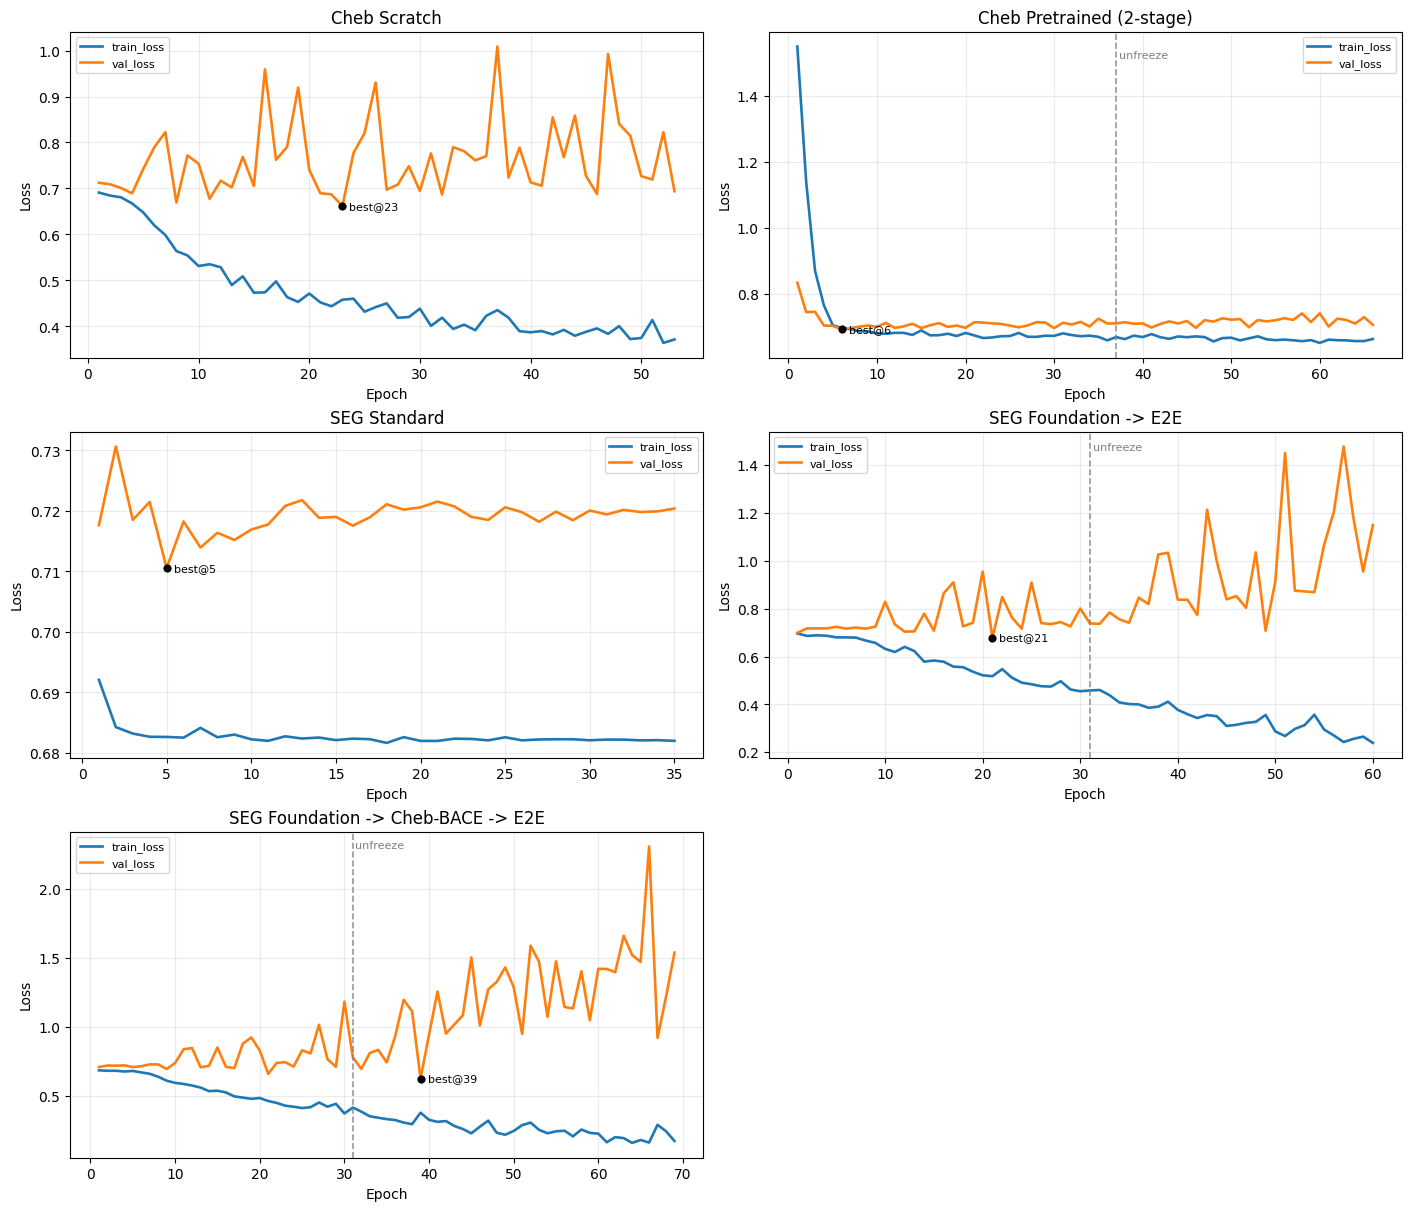

In [10]:
def _plot_history(ax, history, title, *, stage_key='stage'):
    train_loss = np.asarray(history.get('train_loss', []), dtype=np.float32)
    val_loss = np.asarray(history.get('val_loss', []), dtype=np.float32)
    epochs = np.arange(1, len(train_loss) + 1)

    if len(train_loss) == 0:
        ax.text(0.5, 0.5, 'No history available', ha='center', va='center')
        ax.set_title(title)
        ax.set_axis_off()
        return

    ax.plot(epochs, train_loss, label='train_loss', linewidth=1.9)
    if len(val_loss) == len(train_loss):
        ax.plot(epochs, val_loss, label='val_loss', linewidth=1.9)

        best_ep = int(np.nanargmin(val_loss)) + 1
        best_val = float(val_loss[best_ep - 1])
        ax.scatter([best_ep], [best_val], color='black', s=24, zorder=3)
        ax.text(best_ep, best_val, f'  best@{best_ep}', va='center', fontsize=8)

    # Mark transition between frozen and unfreeze stage when available.
    stages = history.get(stage_key, None)
    if isinstance(stages, (list, tuple)) and len(stages) == len(train_loss):
        if 'unfreeze' in stages:
            transition_epoch = int(stages.index('unfreeze')) + 1
            ax.axvline(transition_epoch, linestyle='--', linewidth=1.2, alpha=0.8, color='tab:gray')
            ax.text(transition_epoch + 0.3, ax.get_ylim()[1] * 0.95, 'unfreeze', fontsize=8, color='tab:gray')

    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.grid(alpha=0.25)
    ax.legend(loc='best', fontsize=8)

fig, axes = plt.subplots(3, 2, figsize=(14, 12), constrained_layout=True)
axes = axes.flatten()

plot_items = [
    ('Cheb Scratch', scratch_hist),
    ('Cheb Pretrained (2-stage)', pre_hist),
    ('SEG Standard', seg_hist),
    ('SEG Foundation -> E2E', seg_foundation_e2e_hist),
    ('SEG Foundation -> Cheb-BACE -> E2E', seg_bace_adapted_e2e_hist),
]

for i, (name, hist) in enumerate(plot_items):
    _plot_history(axes[i], hist, name)

# Hide unused subplot
if len(plot_items) < len(axes):
    for j in range(len(plot_items), len(axes)):
        axes[j].set_axis_off()

plt.show()

## Trainingskurven (Overfitting-Check)

Standard-Plot der **Train- und Validation-Losses über Epochen** für:
- ChebNet Scratch
- ChebNet Pretrained (2-stage)
- SEG Standard
- SEG Foundation -> end-to-end
- SEG Foundation -> Cheb-BACE -> end-to-end

,model,threshold,best_val_bce,roc_auc,accuracy,f1
0,cheb_scratch,0.260,0.661549,0.851630,0.776316,0.836538
1,rf_graph_features,0.110,NaN,0.803895,0.703947,0.792627
2,rf_rdkit_descriptors,0.280,NaN,0.800272,0.736842,0.787234
3,seg_foundation_e2e,0.345,0.679111,0.775906,0.736842,0.795918
4,seg_standard,0.050,0.710536,0.775634,0.605263,0.754098
5,seg_bace_adapted_e2e,0.415,0.628250,0.767210,0.730263,0.783069
6,cheb_pretrained,0.380,0.691471,0.508514,0.598684,0.738197


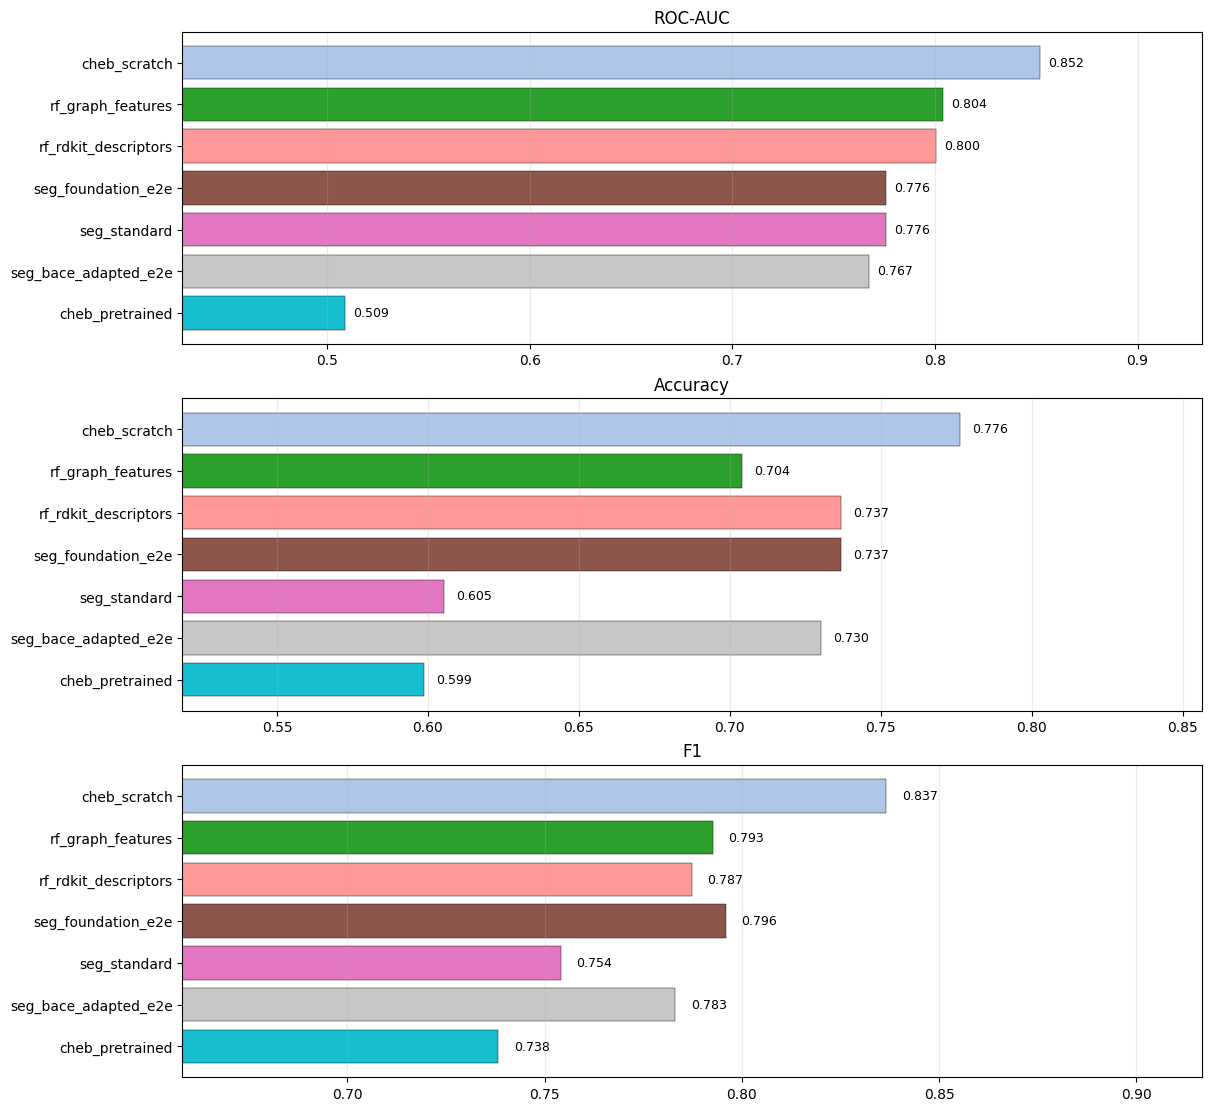

Saved comparison CSV to: C:\Users\robsc\Home\Dev\molfusion2\benchmarking\results\bace_baseline_comparison.csv


In [11]:
comparison_df = pd.DataFrame([
    {'model': 'rf_graph_features', 'threshold': rf_graph_thr, 'best_val_bce': np.nan, **rf_graph_metrics},
    {'model': 'rf_rdkit_descriptors', 'threshold': rf_desc_thr, 'best_val_bce': np.nan, **rf_desc_metrics},
    {'model': 'cheb_scratch', 'threshold': cheb_scratch_thr, 'best_val_bce': cheb_scratch_best_val, **cheb_scratch_metrics},
    {'model': 'cheb_pretrained', 'threshold': cheb_pretrained_thr, 'best_val_bce': cheb_pretrained_best_val, **cheb_pretrained_metrics},
    {'model': 'seg_standard', 'threshold': seg_thr, 'best_val_bce': seg_best_val, **seg_metrics},
    {
        'model': 'seg_foundation_e2e',
        'threshold': seg_foundation_e2e_thr,
        'best_val_bce': seg_foundation_e2e_best_val,
        **seg_foundation_e2e_metrics,
    },
    {
        'model': 'seg_bace_adapted_e2e',
        'threshold': seg_bace_adapted_e2e_thr,
        'best_val_bce': seg_bace_adapted_e2e_best_val,
        **seg_bace_adapted_e2e_metrics,
    },
])

comparison_df = comparison_df.sort_values('roc_auc', ascending=False).reset_index(drop=True)
display(comparison_df)

metrics_to_plot = ['roc_auc', 'accuracy', 'f1']
titles = ['ROC-AUC', 'Accuracy', 'F1']
palette = plt.cm.tab20(np.linspace(0.08, 0.92, len(comparison_df)))

fig, axes = plt.subplots(3, 1, figsize=(12, 11), constrained_layout=True)
for ax, metric_name, title in zip(axes, metrics_to_plot, titles):
    values = comparison_df[metric_name].values
    y = np.arange(len(comparison_df))
    bars = ax.barh(y, values, color=palette, edgecolor='black', linewidth=0.3)
    ax.set_yticks(y)
    ax.set_yticklabels(comparison_df['model'])
    ax.invert_yaxis()
    ax.set_title(title)
    ax.grid(axis='x', alpha=0.25)

    xmin = max(0.0, float(np.min(values) - 0.08))
    xmax = min(1.0, float(np.max(values) + 0.08))
    ax.set_xlim(xmin, xmax)

    for bar, v in zip(bars, values):
        ax.text(v + 0.004, bar.get_y() + bar.get_height() / 2, f'{v:.3f}', va='center', fontsize=9)

plt.show()

out_csv = workspace_root / 'benchmarking' / 'results' / 'bace_baseline_comparison.csv'
comparison_df.to_csv(out_csv, index=False)
print(f'Saved comparison CSV to: {out_csv}')

## Multi-Seed Vergleich (6 Seeds)

Diese Sektion führt **alle 7 Baselines** für mehrere Seeds aus, aggregiert die Metriken (Mittelwert, Std, 95%-CI) und visualisiert die Ergebnisse mit Fehlerbalken.

In [12]:
import random
import time

MULTI_SEEDS = [42, 113, 271, 777, 1337, 2025]
print('Multi-seed setup:', MULTI_SEEDS)

def _set_all_seeds(s):
    random.seed(int(s))
    np.random.seed(int(s))
    torch.manual_seed(int(s))
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(int(s))

def run_all_baselines_for_seed(seed_i, verbose=False):
    _set_all_seeds(seed_i)
    t0 = time.time()

    # RF graph features
    rf_graph_i = RandomForestClassifier(
        n_estimators=1200,
        max_features='sqrt',
        class_weight='balanced',
        random_state=int(seed_i),
        n_jobs=-1,
    )
    rf_graph_i.fit(g_train, train_y_arr)
    rf_graph_valid_proba_i = rf_graph_i.predict_proba(g_valid)[:, 1]
    rf_graph_thr_i = find_best_threshold(valid_y_arr, rf_graph_valid_proba_i)
    rf_graph_test_proba_i = rf_graph_i.predict_proba(g_test)[:, 1]
    rf_graph_metrics_i = classification_metrics(test_y_arr, rf_graph_test_proba_i, threshold=rf_graph_thr_i)

    # RF RDKit descriptors
    rf_desc_i = RandomForestClassifier(
        n_estimators=1200,
        max_features='sqrt',
        class_weight='balanced',
        random_state=int(seed_i),
        n_jobs=-1,
    )
    rf_desc_i.fit(d_train, train_y_arr)
    rf_desc_valid_proba_i = rf_desc_i.predict_proba(d_valid)[:, 1]
    rf_desc_thr_i = find_best_threshold(valid_y_arr, rf_desc_valid_proba_i)
    rf_desc_test_proba_i = rf_desc_i.predict_proba(d_test)[:, 1]
    rf_desc_metrics_i = classification_metrics(test_y_arr, rf_desc_test_proba_i, threshold=rf_desc_thr_i)

    # Cheb scratch
    cheb_scratch_i = ChebPredictor(config=make_bace_config(), device=str(device))
    scratch_hist_i = cheb_scratch_i.fit(
        train_smiles, train_y,
        val_smiles=valid_smiles, val_labels=valid_y,
        num_epochs=VANILLA_FIT_KWARGS['num_epochs'],
        batch_size=VANILLA_FIT_KWARGS['batch_size'],
        learning_rate=VANILLA_FIT_KWARGS['learning_rate'],
        weight_decay=VANILLA_FIT_KWARGS['weight_decay'],
        patience=VANILLA_FIT_KWARGS['patience'],
        seed=int(seed_i),
        verbose=verbose,
    )
    cheb_scratch_best_val_i = float(np.min(scratch_hist_i['val_loss']))
    cheb_scratch_valid_proba_i = cheb_scratch_i.predict_batch(valid_smiles)
    cheb_scratch_thr_i = find_best_threshold(valid_y_arr, cheb_scratch_valid_proba_i)
    cheb_scratch_test_proba_i = cheb_scratch_i.predict_batch(test_smiles)
    cheb_scratch_metrics_i = classification_metrics(test_y_arr, cheb_scratch_test_proba_i, threshold=cheb_scratch_thr_i)

    # Cheb pretrained two-stage
    cheb_pretrained_i = ChebPredictor(config=make_bace_config(), device=str(device))
    pre_hist_i, cheb_pretrained_best_val_i = fit_two_stage(
        cheb_pretrained_i,
        train_smiles, train_y, valid_smiles, valid_y,
        seed=int(seed_i),
        batch_size=CHEB_FIT_KWARGS['batch_size'],
        frozen_epochs=CHEB_FIT_KWARGS['frozen_epochs'],
        unfreeze_epochs=CHEB_FIT_KWARGS['unfreeze_epochs'],
        head_lr=CHEB_FIT_KWARGS['head_lr'],
        encoder_lr=CHEB_FIT_KWARGS['encoder_lr'],
        weight_decay=CHEB_FIT_KWARGS['weight_decay'],
        patience=CHEB_FIT_KWARGS['patience'],
        pretrained_ckpt=pretrained_ckpt,
        verbose=verbose,
    )
    cheb_pretrained_valid_proba_i = cheb_pretrained_i.predict_batch(valid_smiles)
    cheb_pretrained_thr_i = find_best_threshold(valid_y_arr, cheb_pretrained_valid_proba_i)
    cheb_pretrained_test_proba_i = cheb_pretrained_i.predict_batch(test_smiles)
    cheb_pretrained_metrics_i = classification_metrics(test_y_arr, cheb_pretrained_test_proba_i, threshold=cheb_pretrained_thr_i)

    # SEG standard
    seg_i = SEGPredictor(config=make_seg_config(text_embedding_dim=all_emb.shape[1]), device=str(device))
    seg_hist_i = seg_i.fit(
        smiles_list=train_smiles, labels=train_y,
        val_smiles=valid_smiles, val_labels=valid_y,
        text_embeddings=train_emb, val_text_embeddings=valid_emb,
        num_epochs=SEG_FIT_KWARGS['num_epochs'],
        batch_size=SEG_FIT_KWARGS['batch_size'],
        learning_rate=SEG_FIT_KWARGS['learning_rate'],
        weight_decay=SEG_FIT_KWARGS['weight_decay'],
        patience=SEG_FIT_KWARGS['patience'],
        scheduler=SEG_FIT_KWARGS['scheduler'],
        scheduler_patience=SEG_FIT_KWARGS['scheduler_patience'],
        scheduler_factor=SEG_FIT_KWARGS['scheduler_factor'],
        min_lr=SEG_FIT_KWARGS['min_lr'],
        grad_clip=SEG_FIT_KWARGS['grad_clip'],
        seed=int(seed_i),
        verbose=verbose,
    )
    seg_best_val_i = float(np.min(seg_hist_i['val_loss']))
    seg_valid_proba_i = seg_i.predict_batch(valid_smiles, text_embeddings=valid_emb)
    seg_thr_i = find_best_threshold(valid_y_arr, seg_valid_proba_i)
    seg_test_proba_i = seg_i.predict_batch(test_smiles, text_embeddings=test_emb)
    seg_metrics_i = classification_metrics(test_y_arr, seg_test_proba_i, threshold=seg_thr_i)

    # Option 1: foundation -> SEG two-stage
    cheb_foundation_backbone_i = make_cheb_backbone_from_pretraining(pretrained_ckpt, train_smiles)
    seg_foundation_e2e_i = SEGPredictor(
        config=make_seg_pretrained_graph_config(text_embedding_dim=all_emb.shape[1]),
        device=str(device),
    )
    seg_foundation_e2e_i.init_from_cheb(cheb_foundation_backbone_i)
    seg_foundation_e2e_hist_i, seg_foundation_e2e_best_val_i = fit_seg_two_stage(
        seg_foundation_e2e_i,
        train_smiles,
        train_y,
        valid_smiles,
        valid_y,
        train_text_embeddings=train_emb,
        valid_text_embeddings=valid_emb,
        seed=int(seed_i),
        batch_size=SEG_TRANSFER_FIT_KWARGS['batch_size'],
        frozen_epochs=SEG_TRANSFER_FIT_KWARGS['frozen_epochs'],
        unfreeze_epochs=SEG_TRANSFER_FIT_KWARGS['unfreeze_epochs'],
        fusion_lr=SEG_TRANSFER_FIT_KWARGS['fusion_lr'],
        encoder_lr=SEG_TRANSFER_FIT_KWARGS['encoder_lr'],
        weight_decay=SEG_TRANSFER_FIT_KWARGS['weight_decay'],
        patience=SEG_TRANSFER_FIT_KWARGS['patience'],
        verbose=verbose,
    )
    seg_foundation_e2e_valid_proba_i = seg_foundation_e2e_i.predict_batch(valid_smiles, text_embeddings=valid_emb)
    seg_foundation_e2e_thr_i = find_best_threshold(valid_y_arr, seg_foundation_e2e_valid_proba_i)
    seg_foundation_e2e_test_proba_i = seg_foundation_e2e_i.predict_batch(test_smiles, text_embeddings=test_emb)
    seg_foundation_e2e_metrics_i = classification_metrics(test_y_arr, seg_foundation_e2e_test_proba_i, threshold=seg_foundation_e2e_thr_i)

    # Option 2: foundation -> Cheb BACE FT -> SEG two-stage
    seg_bace_adapted_e2e_i = SEGPredictor(
        config=make_seg_pretrained_graph_config(text_embedding_dim=all_emb.shape[1]),
        device=str(device),
    )
    seg_bace_adapted_e2e_i.init_from_cheb(cheb_pretrained_i)
    seg_bace_adapted_e2e_hist_i, seg_bace_adapted_e2e_best_val_i = fit_seg_two_stage(
        seg_bace_adapted_e2e_i,
        train_smiles,
        train_y,
        valid_smiles,
        valid_y,
        train_text_embeddings=train_emb,
        valid_text_embeddings=valid_emb,
        seed=int(seed_i),
        batch_size=SEG_TRANSFER_FIT_KWARGS['batch_size'],
        frozen_epochs=SEG_TRANSFER_FIT_KWARGS['frozen_epochs'],
        unfreeze_epochs=SEG_TRANSFER_FIT_KWARGS['unfreeze_epochs'],
        fusion_lr=SEG_TRANSFER_FIT_KWARGS['fusion_lr'],
        encoder_lr=SEG_TRANSFER_FIT_KWARGS['encoder_lr'],
        weight_decay=SEG_TRANSFER_FIT_KWARGS['weight_decay'],
        patience=SEG_TRANSFER_FIT_KWARGS['patience'],
        verbose=verbose,
    )
    seg_bace_adapted_e2e_valid_proba_i = seg_bace_adapted_e2e_i.predict_batch(valid_smiles, text_embeddings=valid_emb)
    seg_bace_adapted_e2e_thr_i = find_best_threshold(valid_y_arr, seg_bace_adapted_e2e_valid_proba_i)
    seg_bace_adapted_e2e_test_proba_i = seg_bace_adapted_e2e_i.predict_batch(test_smiles, text_embeddings=test_emb)
    seg_bace_adapted_e2e_metrics_i = classification_metrics(test_y_arr, seg_bace_adapted_e2e_test_proba_i, threshold=seg_bace_adapted_e2e_thr_i)

    rows = [
        {'seed': int(seed_i), 'model': 'rf_graph_features', 'threshold': rf_graph_thr_i, 'best_val_bce': np.nan, **rf_graph_metrics_i},
        {'seed': int(seed_i), 'model': 'rf_rdkit_descriptors', 'threshold': rf_desc_thr_i, 'best_val_bce': np.nan, **rf_desc_metrics_i},
        {'seed': int(seed_i), 'model': 'cheb_scratch', 'threshold': cheb_scratch_thr_i, 'best_val_bce': cheb_scratch_best_val_i, **cheb_scratch_metrics_i},
        {'seed': int(seed_i), 'model': 'cheb_pretrained', 'threshold': cheb_pretrained_thr_i, 'best_val_bce': cheb_pretrained_best_val_i, **cheb_pretrained_metrics_i},
        {'seed': int(seed_i), 'model': 'seg_standard', 'threshold': seg_thr_i, 'best_val_bce': seg_best_val_i, **seg_metrics_i},
        {'seed': int(seed_i), 'model': 'seg_foundation_e2e', 'threshold': seg_foundation_e2e_thr_i, 'best_val_bce': seg_foundation_e2e_best_val_i, **seg_foundation_e2e_metrics_i},
        {'seed': int(seed_i), 'model': 'seg_bace_adapted_e2e', 'threshold': seg_bace_adapted_e2e_thr_i, 'best_val_bce': seg_bace_adapted_e2e_best_val_i, **seg_bace_adapted_e2e_metrics_i},
    ]

    if verbose:
        elapsed = time.time() - t0
        print(f'Seed {seed_i} done in {elapsed/60.0:.2f} min')

    return rows

all_rows = []
for i, s in enumerate(MULTI_SEEDS, start=1):
    print(f'[{i}/{len(MULTI_SEEDS)}] Running seed {s} ...')
    seed_rows = run_all_baselines_for_seed(s, verbose=False)
    all_rows.extend(seed_rows)
    seed_df = pd.DataFrame(seed_rows).sort_values('roc_auc', ascending=False).reset_index(drop=True)
    print(seed_df[['model', 'roc_auc', 'accuracy', 'f1']].head(3))

multi_seed_raw_df = pd.DataFrame(all_rows)
display(multi_seed_raw_df.head())
print(f'Collected rows: {len(multi_seed_raw_df)}')

Multi-seed setup: [42, 113, 271, 777, 1337, 2025]
[1/6] Running seed 42 ...
✓ Copied encoder & pooling from ChebPredictor
  Encoder: 2 layers, hidden=64
  Pooling: sum
✓ Copied encoder & pooling from ChebPredictor
  Encoder: 2 layers, hidden=64
  Pooling: sum
                  model   roc_auc  accuracy        f1
0  seg_bace_adapted_e2e  0.804167  0.763158  0.806452
1     rf_graph_features  0.803895  0.703947  0.792627
2  rf_rdkit_descriptors  0.800272  0.736842  0.787234
[2/6] Running seed 113 ...
✓ Copied encoder & pooling from ChebPredictor
  Encoder: 2 layers, hidden=64
  Pooling: sum
✓ Copied encoder & pooling from ChebPredictor
  Encoder: 2 layers, hidden=64
  Pooling: sum
                  model   roc_auc  accuracy        f1
0          cheb_scratch  0.825906  0.743421  0.804020
1  seg_bace_adapted_e2e  0.809058  0.763158  0.810526
2     rf_graph_features  0.808424  0.730263  0.805687
[3/6] Running seed 271 ...
✓ Copied encoder & pooling from ChebPredictor
  Encoder: 2 layers, hid

,seed,model,threshold,best_val_bce,roc_auc,accuracy,f1
0,42,rf_graph_features,0.110,NaN,0.803895,0.703947,0.792627
1,42,rf_rdkit_descriptors,0.280,NaN,0.800272,0.736842,0.787234
2,42,cheb_scratch,0.240,0.667819,0.772101,0.703947,0.803493
3,42,cheb_pretrained,0.385,0.687245,0.573370,0.592105,0.732759
4,42,seg_standard,0.050,0.705539,0.722645,0.605263,0.754098


Collected rows: 42


,model,n_runs,threshold_mean,best_val_bce_mean,best_val_bce_std,roc_auc_mean,roc_auc_std,accuracy_mean,accuracy_std,f1_mean,f1_std,roc_auc_sem,roc_auc_ci95,accuracy_sem,accuracy_ci95,f1_sem,f1_ci95
0,cheb_scratch,6,0.279167,0.653550,0.011750,0.830737,0.035253,0.759868,0.036924,0.825411,0.020927,0.014392,0.028208,0.015074,0.029546,0.008543,0.016745
1,rf_graph_features,6,0.114167,NaN,NaN,0.802732,0.003534,0.705044,0.022181,0.792796,0.010667,0.001443,0.002828,0.009055,0.017748,0.004355,0.008535
2,rf_rdkit_descriptors,6,0.282500,NaN,NaN,0.799909,0.001926,0.732456,0.020665,0.782996,0.021032,0.000786,0.001541,0.008437,0.016536,0.008586,0.016829
3,seg_bace_adapted_e2e,6,0.275000,0.668949,0.021939,0.797615,0.011954,0.755482,0.019256,0.802879,0.022140,0.004880,0.009565,0.007861,0.015408,0.009039,0.017716
4,seg_foundation_e2e,6,0.262500,0.668586,0.019127,0.777597,0.041645,0.720395,0.067958,0.788692,0.049358,0.017002,0.033323,0.027744,0.054377,0.020150,0.039495
5,seg_standard,6,0.110833,0.685437,0.043939,0.688149,0.228679,0.657895,0.088069,0.780284,0.044099,0.093358,0.182981,0.035954,0.070470,0.018003,0.035287
6,cheb_pretrained,6,0.311667,0.691164,0.003109,0.606703,0.059872,0.606360,0.023322,0.746450,0.017831,0.024443,0.047907,0.009521,0.018662,0.007279,0.014268


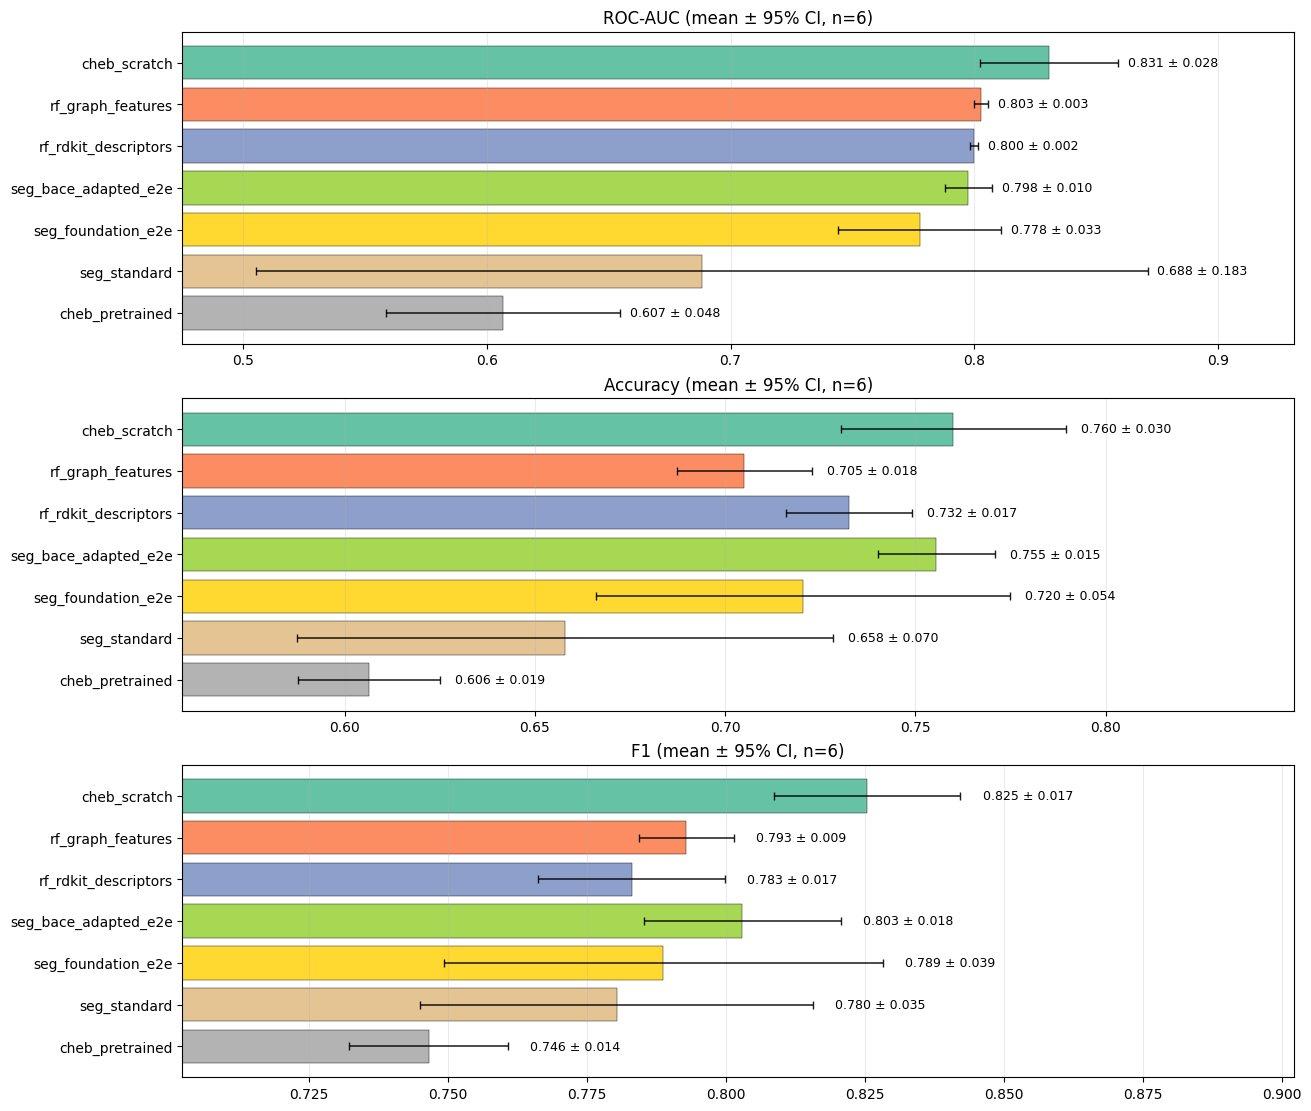

Saved multi-seed raw CSV: C:\Users\robsc\Home\Dev\molfusion2\benchmarking\results\bace_baseline_comparison_multiseed_raw.csv
Saved multi-seed summary CSV: C:\Users\robsc\Home\Dev\molfusion2\benchmarking\results\bace_baseline_comparison_multiseed_summary.csv


In [13]:
def summarize_multi_seed(df):
    g = df.groupby('model', as_index=False)
    summary = g.agg(
        n_runs=('seed', 'count'),
        threshold_mean=('threshold', 'mean'),
        best_val_bce_mean=('best_val_bce', 'mean'),
        best_val_bce_std=('best_val_bce', 'std'),
        roc_auc_mean=('roc_auc', 'mean'),
        roc_auc_std=('roc_auc', 'std'),
        accuracy_mean=('accuracy', 'mean'),
        accuracy_std=('accuracy', 'std'),
        f1_mean=('f1', 'mean'),
        f1_std=('f1', 'std'),
    )

    for metric in ['roc_auc', 'accuracy', 'f1']:
        sem = summary[f'{metric}_std'] / np.sqrt(summary['n_runs'].clip(lower=1))
        summary[f'{metric}_sem'] = sem
        summary[f'{metric}_ci95'] = 1.96 * sem

    return summary.sort_values('roc_auc_mean', ascending=False).reset_index(drop=True)

multi_seed_summary_df = summarize_multi_seed(multi_seed_raw_df)
display(multi_seed_summary_df)

metrics = [
    ('roc_auc', 'ROC-AUC'),
    ('accuracy', 'Accuracy'),
    ('f1', 'F1'),
]

fig, axes = plt.subplots(3, 1, figsize=(13, 11), constrained_layout=True)
palette = plt.cm.Set2(np.linspace(0.08, 0.92, len(multi_seed_summary_df)))

for ax, (m, title) in zip(axes, metrics):
    means = multi_seed_summary_df[f'{m}_mean'].values
    ci95 = multi_seed_summary_df[f'{m}_ci95'].fillna(0.0).values
    y = np.arange(len(multi_seed_summary_df))

    ax.barh(
        y, means,
        xerr=ci95,
        color=palette,
        edgecolor='black',
        linewidth=0.3,
        error_kw={'elinewidth': 1.1, 'capsize': 3, 'alpha': 0.9},
    )
    ax.set_yticks(y)
    ax.set_yticklabels(multi_seed_summary_df['model'])
    ax.invert_yaxis()
    ax.set_title(f'{title} (mean ± 95% CI, n={int(multi_seed_summary_df["n_runs"].iloc[0])})')
    ax.grid(axis='x', alpha=0.25)

    xmin = max(0.0, float(np.min(means - ci95) - 0.03))
    xmax = min(1.0, float(np.max(means + ci95) + 0.06))
    ax.set_xlim(xmin, xmax)

    for yi, mu, ci in zip(y, means, ci95):
        ax.text(mu + ci + 0.004, yi, f'{mu:.3f} ± {ci:.3f}', va='center', fontsize=9)

plt.show()

raw_out = workspace_root / 'benchmarking' / 'results' / 'bace_baseline_comparison_multiseed_raw.csv'
sum_out = workspace_root / 'benchmarking' / 'results' / 'bace_baseline_comparison_multiseed_summary.csv'
multi_seed_raw_df.to_csv(raw_out, index=False)
multi_seed_summary_df.to_csv(sum_out, index=False)
print(f'Saved multi-seed raw CSV: {raw_out}')
print(f'Saved multi-seed summary CSV: {sum_out}')